15 · Mobility (origin-destination matrices)

`od_matrix_to_graph()` turns an OD matrix into a directed, weighted graph:
nodes are zones (polygons or points), edges are observed flows. The edges
presuppose no spatial relation at all, unlike the other three modules; they
are measured interactions, possibly asymmetric.

Two input formats: `matrix_type="edgelist"`, one row per pair, and
`matrix_type="adjacency"`, a square zones × zones matrix. No internet needed.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import city2graph as c2g
import geopandas as gpd
import numpy as np
import pandas as pd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

DATA = nb.repo("examples", "city2graph_examples", "od_matrix_test_files")
print("test data:", DATA)

test data: examples/city2graph_examples/od_matrix_test_files


## 1 · Minimal case: edge list

The repository's test set: 16 zones, seven flows. Too small for a claim
about a city, enough for the contract.

In [2]:
zones = gpd.read_file(DATA / "od_test_zones.geojson")
flows = pd.read_csv(DATA / "od_test_edgelist.csv")

print(f"zones {len(zones)}  columns {list(zones.columns)}  crs {zones.crs}")
print(f"flows {len(flows)}")
print(flows.to_string(index=False))

zones 16  columns ['zone_id', 'geometry']  crs EPSG:4326
flows 10
source target  flow
   G00    G10     5
   G00    G01     2
   G10    G11     3
   G01    G11     7
   G11    G21     8
   G21    G22     6
   G22    G32     4
   G23    G33     6
   G12    G22     5
   G32    G33     3


`zone_id_col` says which column of the zones matches
`source_col`/`target_col` of the matrix.

In [3]:
nodes_od, edges_od = c2g.od_matrix_to_graph(
    flows,
    zones,
    zone_id_col="zone_id",
    matrix_type="edgelist",
    source_col="source",
    target_col="target",
    weight_cols=["flow"],
    directed=True,
)

print(f"nodes {len(nodes_od)}  edges {len(edges_od)}")
print(f"edge index: {edges_od.index.names}")
print(f"columns   : {list(edges_od.columns)}")
edges_od[["flow"]].head()

nodes 16  edges 10
edge index: ['source', 'target']
columns   : ['weight', 'flow', 'geometry']


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/city2graph/mobility.py:135: UserWarning: Geographic CRS detected; distance/length measures may be inaccurate (requirement 3.5)
  _validate_crs(zones_gdf)
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/city2graph/mobility.py:1101: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = zones_gdf.geometry.centroid


flow
source target      
G00    G01        2
       G10        5
G01    G11        7
G10    G11        3
G11    G21        8

The node index keeps the zone identifiers, `G00`, `G01`, so
results join back to the source data. `compute_edge_geometry=True` (the
default) draws the line between the zone centroids.

In [4]:
check("the zone identifiers are preserved",
      set(nodes_od.index) == set(zones["zone_id"]),
      f"example: {list(nodes_od.index)[:4]}")
check("the edges carry geometry",
      edges_od.geometry.notna().all())

[PASS] the zone identifiers are preserved — example: ['G00', 'G10', 'G20', 'G30']
[PASS] the edges carry geometry


True

### In Blender

In [5]:
sg.graphs.clear_scene(keep_anchor=False)
anchor_test = sg.graphs.anchor_from(nodes_od, scale=0.05, name="Anchor_OD_Test")

obj_test = sg.graphs.from_gdf(
    nodes_od, edges_od, name="OD_Test", ref=anchor_test,
    coll="C2G_Mobility_Test",
    markers={"graph_type": "od_matrix_to_graph", "matrix_type": "edgelist"})

print(sg.graphs.summary(obj_test))
check("the test graph is in the scene", obj_test is not None)

{'object': 'OD_Test', 'type': 'MESH', 'num_nodes': 16, 'num_edges': 10, 'is_directed': False, 'vertices': 16, 'mesh_edges': 10, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_weight', 'edge_flow'], 'graph_type': 'od_matrix_to_graph'}
[PASS] the test graph is in the scene


True

Rendered with EEVEE, as everything from notebook 13 onwards. No
terrain or buildings: sixteen invented zones in a test fixture are not
anywhere, and a city under them would say they were.

All three figures look straight down through an orthographic camera
(`render_eevee`'s default) with `look='ink'`, the blackest of the five
backdrops and a turbo ramp wide enough for a flow count over two or three
orders of magnitude. The ramp carries the flow, `edge_flow` here and
`edge_trips` on the real graph.

attributes on the test graph:
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  node_id                      POINT   INT
  edge_weight                  EDGE    FLOAT
  edge_flow                    EDGE    FLOAT
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_flow  ·  edge_flow -> turbo [log]  [2 … 8] on Point


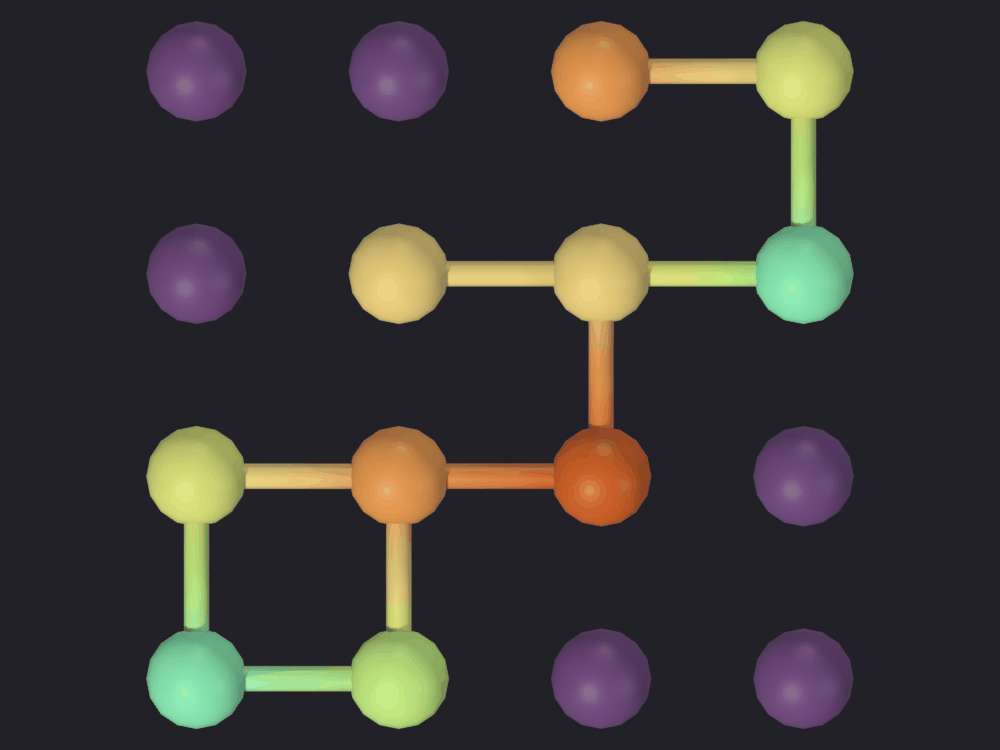

[PASS] 1_od_test.png legible — 20.5% ink (healthy range 0.5–60%)


In [6]:
print("attributes on the test graph:")
for name, domain, dtype in sg.graphs.attributes(obj_test):
    print(f"  {name:<28} {domain:<7} {dtype}")

nb.figure(obj_test, "renders/15_mobility/1_od_test",
          look='ink', color_attribute="edge_flow")

## 2 · A real case: transport flows aggregated to zones

An OD matrix from the São Paulo GTFS feed of notebook 14: count the scheduled
trips from each stop to the next, aggregate the stops to a grid of zones,
sum. The flows come from the timetable, not from ticket validations.

In [7]:
FEED = nb.repo("examples", "GTFS", "sao_paulo.zip")
con = c2g.load_gtfs(FEED)

stops_gdf, segments_gdf = c2g.travel_summary_graph(
    con, start_time="06:00:00", end_time="10:00:00")
con.close()

print(f"stops {len(stops_gdf):,}, segments {len(segments_gdf):,}")

stops 22,143, segments 10,311


### Define the zones

A regular grid over the area with service. In a real study, census tracts;
the mechanics are the same.

In [8]:
from shapely.geometry import box

METRIC_CRS = "EPSG:31983"   # UTM 23S, São Paulo
ZONE_SIDE_M = 2000

# A grid over all 22,000 stops in the feed would be almost entirely empty.
with_service = stops_gdf.loc[
    sorted(set(segments_gdf.index.get_level_values(0))
           | set(segments_gdf.index.get_level_values(1)))
].to_crs(METRIC_CRS)

minx, miny, maxx, maxy = with_service.total_bounds
xs = np.arange(minx, maxx + ZONE_SIDE_M, ZONE_SIDE_M)
ys = np.arange(miny, maxy + ZONE_SIDE_M, ZONE_SIDE_M)

cells = []
for i, x in enumerate(xs[:-1]):
    for j, y in enumerate(ys[:-1]):
        cells.append({"zone_id": f"Z{i:02d}{j:02d}",
                     "geometry": box(x, y, x + ZONE_SIDE_M, y + ZONE_SIDE_M)})
grid = gpd.GeoDataFrame(cells, crs=METRIC_CRS)

with_stop = gpd.sjoin(grid, with_service[["geometry"]],
                      how="inner", predicate="contains")
real_zones = grid[grid["zone_id"].isin(with_stop["zone_id"])].reset_index(drop=True)

print(f"full grid    : {len(grid)} cells of {ZONE_SIDE_M} m")
print(f"with service : {len(real_zones)} zones")

full grid    : 1248 cells of 2000 m
with service : 322 zones


### Assign each stop to its zone and aggregate the flows

In [9]:
stop_zone = gpd.sjoin(with_service[["geometry"]], real_zones,
                      how="inner", predicate="within")["zone_id"]

od = (segments_gdf.reset_index()
      .assign(origin=lambda d: d["from_stop_id"].map(stop_zone),
      destination=lambda d: d["to_stop_id"].map(stop_zone))
      .dropna(subset=["origin", "destination"]))

# Movements within a single zone are not flow between zones.
od = od[od["origin"] != od["destination"]]

matrix = (od.groupby(["origin", "destination"], as_index=False)
          .agg(trips=("frequency", "sum"),
          mean_time_s=("travel_time_sec", "mean")))

print(f"OD pairs between zones: {len(matrix)}")
print(matrix.sort_values("trips", ascending=False).head(8).to_string(index=False))

OD pairs between zones: 852
origin destination   trips  mean_time_s
 Z1412       Z1312 3524511   130.910777
 Z1413       Z1313 3105027   260.646472
 Z1314       Z1313 2705897   153.377747
 Z1412       Z1413 2663797   129.693016
 Z1620       Z1520 1996193   151.934171
 Z1313       Z1413 1947722   183.006537
 Z1517       Z1417 1915715   145.890958
 Z1421       Z1420 1913557   110.955739


### The conversion

`threshold` discards pairs below a minimum weight, the usual way of removing
long-tail noise before drawing.

In [10]:
nodes_zone, edges_zone = c2g.od_matrix_to_graph(
    matrix,
    real_zones,
    zone_id_col="zone_id",
    matrix_type="edgelist",
    source_col="origin",
    target_col="destination",
    weight_cols=["trips", "mean_time_s"],
    threshold=2.0,
    threshold_col="trips",
    directed=True,
    include_self_loops=False,
)

print(f"nodes {len(nodes_zone)}  edges {len(edges_zone)} (threshold 2 trips)")
print("\ntrips per pair:")
print(edges_zone["trips"].describe().to_string())

nodes 322  edges 852 (threshold 2 trips)

trips per pair:
count    8.520000e+02
mean     3.438530e+05
std      4.073042e+05
min      8.270000e+02
25%      7.865425e+04
50%      1.860820e+05
75%      4.658055e+05
max      3.524511e+06


### Asymmetry

Observed flows need not be symmetric, and the construction respects that.

In [11]:
pairs = {(a, b) for a, b in edges_zone.index}
reciprocal = sum(1 for a, b in pairs if (b, a) in pairs)
print(f"directed pairs        : {len(pairs)}")
print(f"with a return leg     : {reciprocal}")
print(f"one-way only          : {len(pairs) - reciprocal}")

check("the graph preserves direction", len(pairs) - reciprocal > 0,
      "a symmetric graph would have lost this information")

directed pairs        : 852
with a return leg     : 590
one-way only          : 262
[PASS] the graph preserves direction — a symmetric graph would have lost this information


True

### In Blender

In [12]:
anchor = sg.graphs.anchor_from(nodes_zone, scale=0.001, name="Anchor_OD")

obj_od = sg.graphs.from_gdf(
    nodes_zone, edges_zone, name="OD_Zones_SaoPaulo", ref=anchor,
    coll="C2G_Mobility",
    markers={"graph_type": "od_matrix_to_graph",
             "source": "GTFS São Paulo 06:00-10:00",
             "zone_side_m": ZONE_SIDE_M})

print(sg.graphs.summary(obj_od))
print("\nattributes:")
for name, domain, dtype in sg.graphs.attributes(obj_od):
    print(f"  {name:<28} {domain:<7} {dtype}")

{'object': 'OD_Zones_SaoPaulo', 'type': 'MESH', 'num_nodes': 322, 'num_edges': 557, 'is_directed': False, 'vertices': 322, 'mesh_edges': 557, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_weight', 'edge_trips', 'edge_mean_time_s'], 'graph_type': 'od_matrix_to_graph'}

attributes:
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  node_id                      POINT   INT
  edge_weight                  EDGE    FLOAT
  edge_trips                   EDGE    FLOAT
  edge_mean_time_s             EDGE    FLOAT


`edge_trips` sums the scheduled trips over each zone pair. It
is heavily skewed: the central pairs carry many times the median and on a
linear scale would flatten the rest into the bottom stop, so the top
percentile is clipped.

edge_trips domain: EDGE
  Promoted 3 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_trips  ·  edge_trips -> turbo [log]  [827 … 1.349e+06] on Point


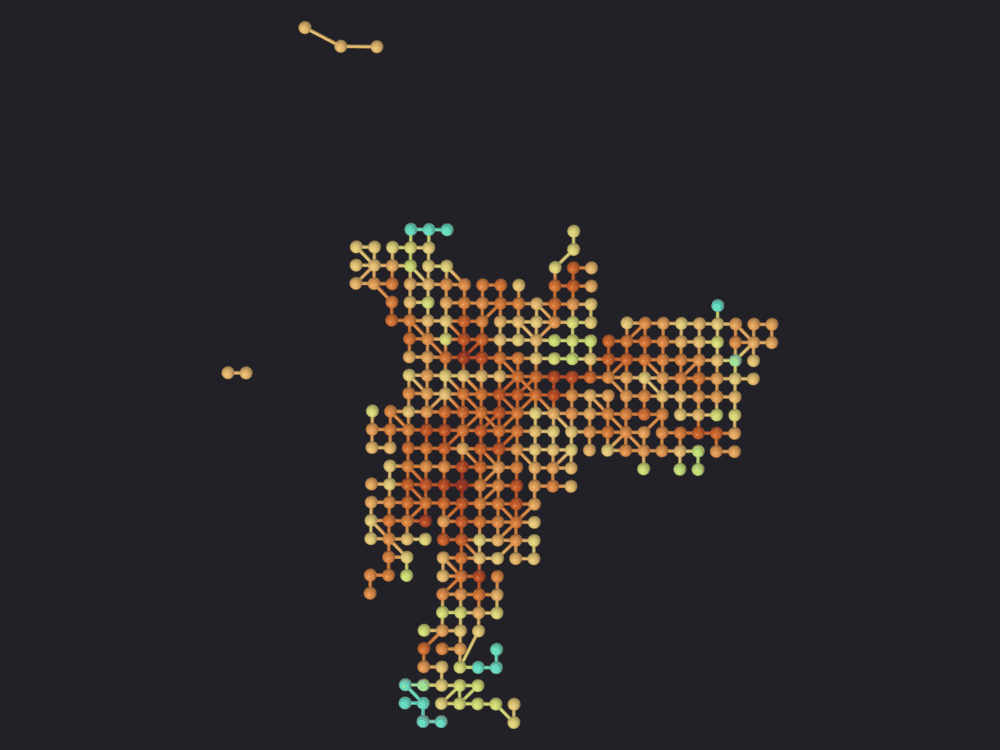

[PASS] 2_od_zones.png legible — 8.5% ink (healthy range 0.5–60%)


In [13]:
print("edge_trips domain:", sg.render.attribute_domain(obj_od, "edge_trips"))

nb.figure(obj_od, "renders/15_mobility/2_od_zones",
          look='ink', color_attribute="edge_trips",
          clip_high_pct=98)

### The zones under the flows

The neighborhood notebooks put extruded OSM buildings under their graphs;
pointless here, where the zones are 2 km squares, the frame is tens of
kilometers across and a building would be a fraction of a pixel. The zones
themselves are the context, and already built.

In [14]:
objs_zones = sg.graphs.from_features(real_zones, name="OD_Zones", ref=anchor,
                                     coll="C2G_Mobility")

# The polygons arrive at the graph's exact z and would z-fight. Drop them by
# the one meter of real ground `sg.context.settle()` leaves under a terrain.
for obj in objs_zones:
    obj.location.z -= 0.001
# Not `kind="ground"`, which renders nine levels of blue off the background and
# disappears: that albedo assumes buildings stand on it catching light, and a
# flat quad has none. These zones are the only context here, so they take the
# lightest of the three materials.
sg.context.style_context(objs_zones, kind="buildings")

# Section 1's test graph is still in the scene at fifty times this scale, and
# `isolate=False` would draw it straight across the frame.
if obj_test is not None:
    obj_test.hide_render = True

Using reference projection: center=(-23.538768, -46.660585), scale=0.001
Created 1 object(s) from GeoDataFrame with 322 features


  Promoted 3 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_trips  ·  edge_trips -> turbo [log]  [827 … 1.349e+06] on Point


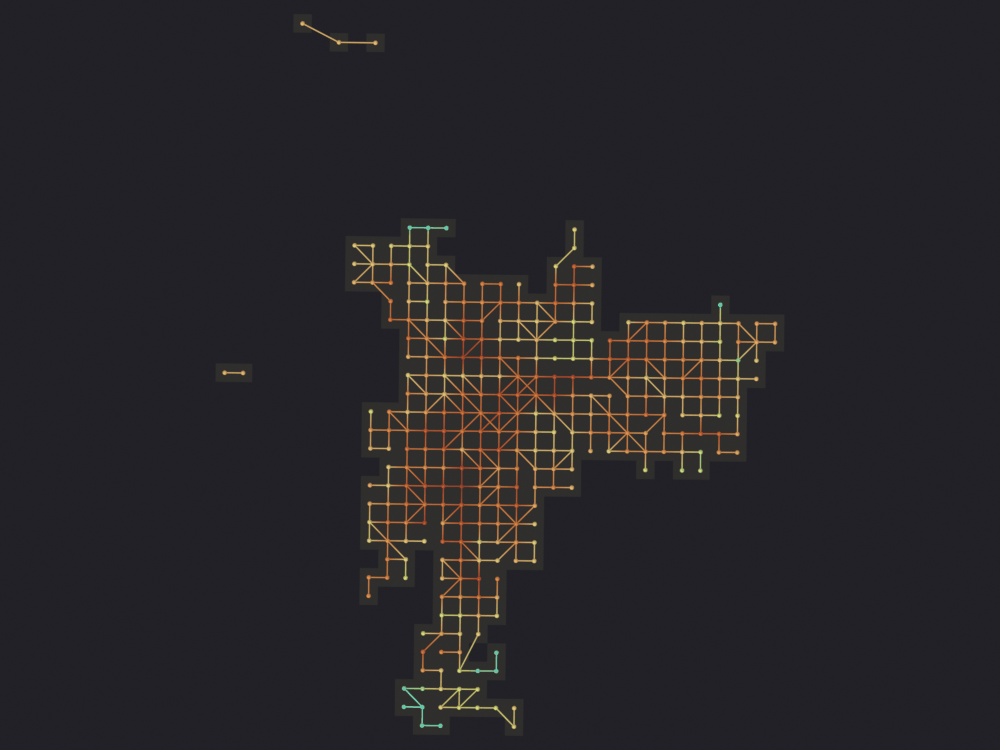

[PASS] 3_od_zones_context.png legible — 14.4% ink (healthy range 0.5–100%)


In [15]:
# These nodes are 2 km apart, so the 0.35 default draws them 1.4 km wide and
# every zone vanishes under its own node. 0.12 leaves the grid visible.
#
# Ink ceiling lifted for the usual overhead reason (notebook 13).
path = nb.render(obj_od, "renders/15_mobility/3_od_zones_context",
                 isolate=False, look='ink',
                 color_attribute="edge_trips", clip_high_pct=98,
                 node_fraction=0.12, verbose=False)
nb.show(path)
nb.check_render(path, maximum=1.0)

if obj_test is not None:
    obj_test.hide_render = False

In [16]:
sg.graphs.visualize(obj_od, node_size=0.04, edge_thickness=0.006)
result, message = sg.graphs.color_by(obj_od, "edge_trips", colormap="magma")
print(message)
sg.graphs.frame(obj_od)

  Promoted 3 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_trips  ·  edge_trips -> magma [log]  [827 … 1.349e+06] on Point
edge_trips -> magma


bpy.data.objects['OD_Zones_SaoPaulo']

## 3 · The other format: adjacency matrix

A square matrix instead of a list of pairs: a DataFrame indexed by zone, or a
NumPy array, in which case the labels come from the order of `zones_gdf`.

In [17]:
ids = list(real_zones["zone_id"])
position = {z: i for i, z in enumerate(ids)}

adjacency = np.zeros((len(ids), len(ids)))
for row in matrix.itertuples(index=False):
    adjacency[position[row.origin], position[row.destination]] = row.trips

adjacency_df = pd.DataFrame(adjacency, index=ids, columns=ids)
print(f"matrix {adjacency_df.shape}, {int((adjacency > 0).sum())} non-zero cells")

nodes_adj, edges_adj = c2g.od_matrix_to_graph(
    adjacency_df,
    real_zones,
    zone_id_col="zone_id",
    matrix_type="adjacency",
    directed=True,
    include_self_loops=False,
)

print(f"edges from the adjacency matrix: {len(edges_adj)}")
print(f"edges from the edge list       : {len(edges_zone)} (with threshold 2)")

unthresholded = (matrix["trips"] > 0).sum()
check("adjacency matrix and edge list describe the same thing",
      len(edges_adj) == unthresholded,
      f"{len(edges_adj)} vs {unthresholded} non-zero pairs")

matrix (322, 322), 852 non-zero cells
edges from the adjacency matrix: 852
edges from the edge list       : 852 (with threshold 2)
[PASS] adjacency matrix and edge list describe the same thing — 852 vs 852 non-zero pairs


True

## 4 · The SciGraphs operator

The GUI route: `c2g_load_od_matrix` stores the CSV in the scene,
`c2g_od_to_graph` crosses it with a Blender zones object.

In [18]:
csv_tmp = nb.out("03_mobility", "od_matrix.csv")
matrix.rename(columns={"origin": "source", "destination": "target",
              "trips": "flow"}).to_csv(csv_tmp, index=False)

result = bpy.ops.scigraphs.c2g_load_od_matrix(filepath=str(csv_tmp))
print("c2g_load_od_matrix ->", result)
print("matrix in the scene:", "c2g_od_data" in bpy.context.scene.keys())

Info: Loaded OD matrix: 852 rows from notebooks/out/03_mobility/od_matrix.csv
c2g_load_od_matrix -> {'FINISHED'}
matrix in the scene: True


> **Operator limitation.** The panel shows fields for the
> source and target columns (`od_source_col`, `od_target_col`) but does not
> pass them to `od_matrix_to_graph()`, which keeps its defaults `"source"`
> and `"target"`. Hence the rename above; with other names, call the
> function directly.

## 5 · Save

In [19]:
out_dir = nb.out("03_mobility")
out_dir.mkdir(parents=True, exist_ok=True)

sg.graphs.save_gdf(real_zones, out_dir / "zones.gpkg")
sg.graphs.save_gdf(edges_zone, out_dir / "od_flows.gpkg")
matrix.to_csv(out_dir / "od_matrix_long.csv", index=False)

print("written to", nb.rel(out_dir))
for f in sorted(out_dir.iterdir()):
    print("  ", f.name, f"{f.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/03_mobility
   od_flows.gpkg 250 kB
   od_matrix.csv 28 kB
   od_matrix_long.csv 28 kB
   zones.gpkg 168 kB


## Rendering

The PNGs land in `notebooks/out/renders/`. Notebook 13 explains `draw_eevee`.

> The Vulkan warning still applies to the SciGraphs engine that notebooks 17
> and 06 keep for edge sparsification: on Blender's **Vulkan** backend (the
> Linux default) `gpu.state.point_size_set` does nothing for the add-on's
> shaders, so `POINT` and `DISK` nodes come out **1 pixel** wide. Start
> Blender with `--gpu-backend opengl` for any render you mean to look at.

## Summary

| Format | Call | Result |
|---|---|---|
| List of pairs | `od_matrix_to_graph(..., matrix_type="edgelist")` | `OD_Zones_SaoPaulo` |
| Square matrix | `od_matrix_to_graph(..., matrix_type="adjacency")` | the same pairs |

Real OD matrices: commuting censuses, transit smart-card data, bike-share
records. New York subway ridership estimates: <https://data.ny.gov>.

Next: **04 · Proximity graphs**.